## Importting Libraries for EDA
Necessary libraries:
- pandas
- matplotlib 
- numpy

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
from sklearn.neighbors import BallTree

## 1.1 Dataset Overview

The project combines two datasets:
- Historical Disaster Dataset (Philippines)
- Philippine City Population Dataset
<p> The historical disaster dataset contains records of past disaster occurring in different Philippine locations, </br> while population dataset provides demographic information ised to normalize disaster impacts.</p>

In [48]:
# loading philippine city population dataset:
PH_population_df=pd.read_csv("../data/raw/philippine_population.csv")
#loading hitorical philippine disaster dataset:
PH_disaster_df=pd.read_csv("../data/raw/philippine_disaster_dataset.csv")

print(f"the shape of the population dataset is compose of {PH_population_df.shape[0]} rows and {PH_population_df.shape[1]} columns")
print(f"the shape of the disaster dataset is compose of {PH_disaster_df.shape[0]} rows and {PH_disaster_df.shape[1]} columns")

the shape of the population dataset is compose of 313 rows and 9 columns
the shape of the disaster dataset is compose of 1815 rows and 33 columns


In [49]:
PH_population_df.head()

,city,lat,lng,country,iso2,admin_name,capital,population,population_proper
0,Manila,14.5958,120.9772,Philippines,PH,Manila,primary,13484482,1902590
1,Quezon City,14.6500,121.0475,Philippines,PH,Quezon,admin,3084270,3084270
2,Zamboanga City,6.9042,122.0761,Philippines,PH,Zamboanga,admin,2100000,1018849
3,Caloocan City,14.6500,120.9667,Philippines,PH,Caloocan,admin,1712945,1712945
4,Taguig City,14.5167,121.0500,Philippines,PH,Taguig,admin,1308085,1308085


In [50]:
PH_disaster_df.head()

,disaster_id,disaster_location_id,geoname_id,precision_code,place_name,latitude,longitude,location_type_code,geoname_adm_code,geoname_adm_name,...,country_iso3,start_isodate,end_isodate,no_killed,no_injured,no_affected,no_homeless,total_affected,total_dam_usd,even_split_dam_usd
0,1980-9364,1980-9364_1699597,1699597,1,Mindanao,8.00000,125.00000,ISL,6295630|6255147|PH|00,Earth|Asia|Philippines|Mindanao,...,PHL,1980-1,1980-7,0,0,1002100,0,1002100,0.000000e+00,0.000000e+00
1,1980-314,1980-314_1688177,1688177,1,Santa Fe,16.20000,120.88333,ADM3,6295630|6255147|PH|02|1697456|1688177,Earth|Asia|Philippines|Cagayan Valley|Province...,...,PHL,1980-11-11,1980-11-11,50,0,0,0,0,0.000000e+00,0.000000e+00
2,1980-99,1980-99_7521297,7521297,4,Cagayan Valley,17.65667,121.73333,ADM1,6295630|6255147|PH|02,Earth|Asia|Philippines|Cagayan Valley,...,PHL,1980-11-6,1980-11-6,101,0,775000,229000,1004000,2.862834e+08,7.157085e+07
3,1980-99,1980-99_7521301,7521301,4,Ilocos,16.97917,120.52083,ADM1,6295630|6255147|PH|01,Earth|Asia|Philippines|Ilocos,...,PHL,1980-11-6,1980-11-6,101,0,775000,229000,1004000,2.862834e+08,7.157085e+07
4,1980-99,1980-99_7521305,7521305,4,Central Luzon,15.30714,120.79762,ADM1,6295630|6255147|PH|03,Earth|Asia|Philippines|Central Luzon,...,PHL,1980-11-6,1980-11-6,101,0,775000,229000,1004000,2.862834e+08,7.157085e+07


In [51]:
PH_population_df.describe()

,lat,lng,population,population_proper
count,313.000000,313.000000,3.130000e+02,3.130000e+02
mean,12.525644,122.428649,2.284904e+05,1.896899e+05
std,2.790347,1.645367,8.063777e+05,3.004583e+05
min,4.661500,118.744000,1.305200e+04,1.305200e+04
25%,10.466700,120.985000,5.918400e+04,5.918400e+04
50%,13.596100,122.235200,9.473600e+04,9.473600e+04
75%,14.483300,123.796400,1.773330e+05,1.773330e+05
max,18.606100,126.233300,1.348448e+07,3.084270e+06


## 1.2 Missing Value Analysis
<p> Before preprocessing, the dataset was inspected for missing values to determine whether imputation or removal was necessary</p>

In [52]:
#checking for missing values in the disaster dataset

def check_missing_values(df):
    missing=df.isnull().sum()
    return missing[missing>0].sort_values(ascending=False)


print(f"Philippine population dataset has missing values in the following columns:\n{check_missing_values(PH_population_df)}")
print(f"Philippine disaster dataset has missing values in the following columns:\n{check_missing_values(PH_disaster_df)}")



Philippine population dataset has missing values in the following columns:
capital       235
admin_name      1
dtype: int64
Philippine disaster dataset has missing values in the following columns:
disaster_subsubtype     1809
associated_disaster2    1436
associated_disaster      988
event_name               564
disaster_subtype         101
longitude                 63
latitude                  63
end_isodate               57
start_isodate             57
location                  40
total_dam_usd              4
dtype: int64


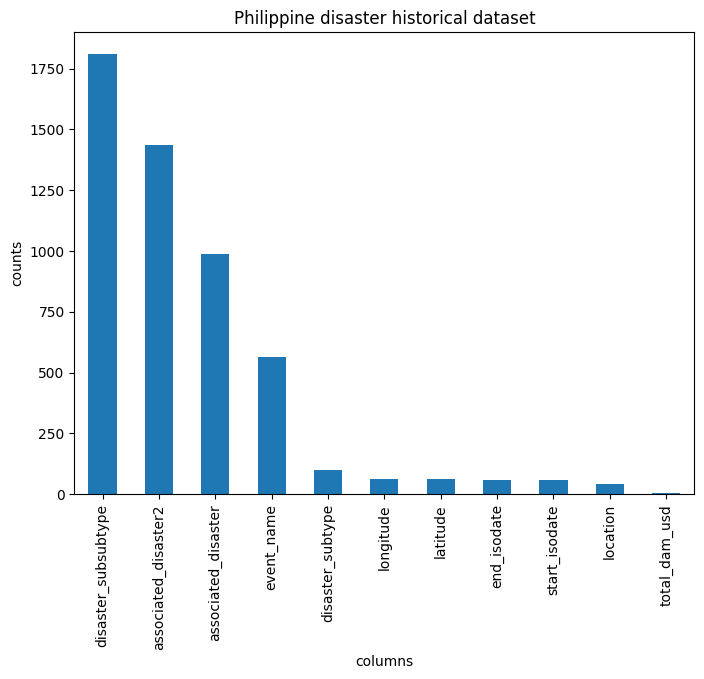

In [53]:
# plotting missing values in each dataset using bar chart
def plotting_missing_values(df,dataset_name):
    missing=check_missing_values(df)
    if not missing.empty:
        plt.figure(figsize=(8,6))
        missing.plot(kind="bar")

        plt.title(dataset_name)
        plt.xlabel("columns")
        plt.ylabel("counts")
        plt.show()

plotting_missing_values(PH_disaster_df, "Philippine disaster historical dataset")




## 1.3 Checking duplicating records

Duplicate  Value Analysis:

- Duplicate records were examined in both the Historical Disaster Dataset and the Philippine City Population Dataset to ensure data integrity before preprocessing and model development. Duplicate observations can lead to biased statistical analysis and cause the machine learning model to overrepresent certain disaster events or locations.

- The analysis showed that no duplicate records were found in either dataset. This confirms that each disaster event and city population record is unique, eliminating the need for duplicate removal during the data cleaning process.

In [54]:
print(f"number of duplicated analysis of historical disaster dataset:{PH_disaster_df.duplicated().sum()}")
print(f"number of duplicated analysis of philippine city population dataset:{PH_population_df.duplicated().sum()}")



number of duplicated analysis of historical disaster dataset:0
number of duplicated analysis of philippine city population dataset:0


## 1.4 Summary of Statistics

In [55]:
PH_disaster_df.describe()


,geoname_id,precision_code,latitude,longitude,location_class,geographic_exactness,year,no_killed,no_injured,no_affected,no_homeless,total_affected,total_dam_usd,even_split_dam_usd
count,1.815000e+03,1815.000000,1752.000000,1752.000000,1815.000000,1815.000000,1815.000000,1815.000000,1815.000000,1.815000e+03,1.815000e+03,1.815000e+03,1.811000e+03,1.815000e+03
mean,2.590997e+06,2.591736,13.166454,122.372653,1.241322,1.030303,2002.147107,126.651791,1226.478237,6.575696e+05,1.703122e+04,6.758273e+05,6.593914e+07,8.949897e+06
std,2.096457e+06,1.241171,3.366347,1.829780,0.698202,0.171467,8.908011,388.602185,11589.979139,1.103525e+06,9.265835e+04,1.123821e+06,1.469423e+08,3.319692e+07
min,1.679428e+06,1.000000,4.866670,117.066670,1.000000,1.000000,1980.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.695357e+06,1.000000,10.570830,120.916670,1.000000,1.000000,1994.000000,7.000000,0.000000,2.000000e+04,0.000000e+00,2.500000e+04,0.000000e+00,0.000000e+00
50%,1.708026e+06,3.000000,14.166670,121.733330,1.000000,1.000000,2006.000000,26.000000,7.000000,2.358850e+05,0.000000e+00,2.397630e+05,6.581697e+06,7.571153e+05
75%,1.726279e+06,3.000000,15.583330,124.000000,1.000000,1.000000,2009.000000,77.000000,37.000000,7.584230e+05,0.000000e+00,8.021750e+05,5.022207e+07,4.847284e+06
max,1.118568e+07,8.000000,20.457980,126.416670,4.000000,2.000000,2012.000000,5956.000000,123939.000000,6.243998e+06,1.110020e+06,6.246664e+06,1.128812e+09,5.644058e+08


In [56]:
PH_population_df.describe()

,lat,lng,population,population_proper
count,313.000000,313.000000,3.130000e+02,3.130000e+02
mean,12.525644,122.428649,2.284904e+05,1.896899e+05
std,2.790347,1.645367,8.063777e+05,3.004583e+05
min,4.661500,118.744000,1.305200e+04,1.305200e+04
25%,10.466700,120.985000,5.918400e+04,5.918400e+04
50%,13.596100,122.235200,9.473600e+04,9.473600e+04
75%,14.483300,123.796400,1.773330e+05,1.773330e+05
max,18.606100,126.233300,1.348448e+07,3.084270e+06


In [57]:
PH_disaster_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1815 entries, 0 to 1814
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   disaster_id           1815 non-null   object 
 1   disaster_location_id  1815 non-null   object 
 2   geoname_id            1815 non-null   int64  
 3   precision_code        1815 non-null   int64  
 4   place_name            1815 non-null   object 
 5   latitude              1752 non-null   float64
 6   longitude             1752 non-null   float64
 7   location_type_code    1815 non-null   object 
 8   geoname_adm_code      1815 non-null   object 
 9   geoname_adm_name      1815 non-null   object 
 10  location_class        1815 non-null   int64  
 11  geographic_exactness  1815 non-null   int64  
 12  year                  1815 non-null   int64  
 13  event_name            1251 non-null   object 
 14  location              1775 non-null   object 
 15  disaster_group       

In [58]:
PH_population_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               313 non-null    object 
 1   lat                313 non-null    float64
 2   lng                313 non-null    float64
 3   country            313 non-null    object 
 4   iso2               313 non-null    object 
 5   admin_name         312 non-null    object 
 6   capital            78 non-null     object 
 7   population         313 non-null    int64  
 8   population_proper  313 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 22.1+ KB


## 1.5 Data Cleaning

Real-world disaster datasets often contain inconsistencies, missing values, and duplicated information.

The following preprocessing steps were performed:

- Removed duplicate records
- Handled missing numerical values
- Converted date columns into datetime format
- Standardized disaster categories
- Corrected inconsistent location names
- Converting disaster type value into understandable terms

These steps improve the quality of the dataset and ensure reliable model training.

In [59]:
PH_disaster_df.isnull().sum()

disaster_id                0
disaster_location_id       0
geoname_id                 0
precision_code             0
place_name                 0
latitude                  63
longitude                 63
location_type_code         0
geoname_adm_code           0
geoname_adm_name           0
location_class             0
geographic_exactness       0
year                       0
event_name               564
location                  40
disaster_group             0
disaster_subgroup          0
disaster_type              0
disaster_subtype         101
disaster_subsubtype     1809
associated_disaster      988
associated_disaster2    1436
country_name               0
country_iso3               0
start_isodate             57
end_isodate               57
no_killed                  0
no_injured                 0
no_affected                0
no_homeless                0
total_affected             0
total_dam_usd              4
even_split_dam_usd         0
dtype: int64

In [60]:
PH_population_df.isnull().sum()


city                   0
lat                    0
lng                    0
country                0
iso2                   0
admin_name             1
capital              235
population             0
population_proper      0
dtype: int64

### Removing Missing Values
Removing missing values in specific columns and making a copy of the datasets.

In [61]:

PH_disaster_df=PH_disaster_df.dropna(subset=[ "location","disaster_type","start_isodate","end_isodate","latitude","longitude"]).copy()
PH_population_df.dropna(subset=["city","population_proper"])

,city,lat,lng,country,iso2,admin_name,capital,population,population_proper
0,Manila,14.5958,120.9772,Philippines,PH,Manila,primary,13484482,1902590
1,Quezon City,14.6500,121.0475,Philippines,PH,Quezon,admin,3084270,3084270
2,Zamboanga City,6.9042,122.0761,Philippines,PH,Zamboanga,admin,2100000,1018849
3,Caloocan City,14.6500,120.9667,Philippines,PH,Caloocan,admin,1712945,1712945
4,Taguig City,14.5167,121.0500,Philippines,PH,Taguig,admin,1308085,1308085
...,...,...,...,...,...,...,...,...,...
308,Mataas Na Kahoy,13.9589,121.1138,Philippines,PH,Batangas,NaN,30621,30621
309,Placer,9.6570,125.6016,Philippines,PH,Surigao del Norte,NaN,30442,30442
310,Bayang,7.7930,124.1920,Philippines,PH,Lanao del Sur,NaN,30227,30227
311,Baclayon,9.6227,123.9135,Philippines,PH,Bohol,minor,22754,22754


In [62]:
print(PH_disaster_df.isna().sum())
print(PH_population_df.isna().sum())

disaster_id                0
disaster_location_id       0
geoname_id                 0
precision_code             0
place_name                 0
latitude                   0
longitude                  0
location_type_code         0
geoname_adm_code           0
geoname_adm_name           0
location_class             0
geographic_exactness       0
year                       0
event_name               508
location                   0
disaster_group             0
disaster_subgroup          0
disaster_type              0
disaster_subtype          76
disaster_subsubtype     1698
associated_disaster      897
associated_disaster2    1328
country_name               0
country_iso3               0
start_isodate              0
end_isodate                0
no_killed                  0
no_injured                 0
no_affected                0
no_homeless                0
total_affected             0
total_dam_usd              4
even_split_dam_usd         0
dtype: int64
city                   0
lat  

### Replacing Missing Values
Replaced Missing values with zero in the disaster imapct columns.

In [63]:
cols = [
    "no_killed",
    "no_injured",
    "no_affected",
    "no_homeless",
    "total_dam_usd"
]
PH_disaster_df[cols]=PH_disaster_df[cols].fillna(0)

### Fixing Datatypes
Changing the Object datatypes in "start_isodate" and "end_isodate" coulmns into datetime datatype


In [64]:
PH_disaster_df["start_isodate"].unique()[:30]


array(['1980-1', '1980-11-11', '1980-11-6', '1980-7-25', '1981-10-9',
       '1981-12-25', '1981-11-7', '1981-9-20', '1981-7-4', '1982-1-11',
       '1982-6-23', '1982-1-22', '1982-12-2', '1982-10-12', '1982-9-5',
       '1982-3-22', '1983-9-23', '1983-9-16', '1983-8-18', '1983-7-14',
       '1984-9-1', '1984-11-3', '1984-9-10', '1984-8-27', '1985-1-26',
       '1985-6-20', '1985-3-18', '1985-10-21', '1985-10-15', '1986-6-28'],
      dtype=object)

In [65]:
print("Before fixing date")
print(PH_disaster_df["start_isodate"].notna().sum())
print(PH_disaster_df["end_isodate"].notna().sum())

Before fixing date
1704
1704


In [66]:
# standardardizing date:

def fix_date(date):
    if pd.isna(date):
        return pd.NA
    date=str(date).strip()

    if re.fullmatch(r"\d{4}-\d{1,2}",date):
        return date +"-1"
    return date

PH_disaster_df["start_isodate"]=PH_disaster_df["start_isodate"].apply(fix_date)
PH_disaster_df["end_isodate"]=PH_disaster_df["end_isodate"].apply(fix_date)


In [67]:
# Converting into datetime datatype:

PH_disaster_df["start_date"]=pd.to_datetime(PH_disaster_df["start_isodate"],format="mixed",errors ="coerce")
PH_disaster_df["end_date"]=pd.to_datetime(PH_disaster_df["end_isodate"],format="mixed",errors ="coerce")
PH_disaster_df[["start_date","end_date"]].info()



<class 'pandas.core.frame.DataFrame'>
Index: 1704 entries, 0 to 1751
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   start_date  1704 non-null   datetime64[ns]
 1   end_date    1704 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 39.9 KB


In [68]:
PH_disaster_df.head(10)

,disaster_id,disaster_location_id,geoname_id,precision_code,place_name,latitude,longitude,location_type_code,geoname_adm_code,geoname_adm_name,...,end_isodate,no_killed,no_injured,no_affected,no_homeless,total_affected,total_dam_usd,even_split_dam_usd,start_date,end_date
0,1980-9364,1980-9364_1699597,1699597,1,Mindanao,8.00000,125.00000,ISL,6295630|6255147|PH|00,Earth|Asia|Philippines|Mindanao,...,1980-7-1,0,0,1002100,0,1002100,0.000000e+00,0.000000e+00,1980-01-01,1980-07-01
1,1980-314,1980-314_1688177,1688177,1,Santa Fe,16.20000,120.88333,ADM3,6295630|6255147|PH|02|1697456|1688177,Earth|Asia|Philippines|Cagayan Valley|Province...,...,1980-11-11,50,0,0,0,0,0.000000e+00,0.000000e+00,1980-11-11,1980-11-11
2,1980-99,1980-99_7521297,7521297,4,Cagayan Valley,17.65667,121.73333,ADM1,6295630|6255147|PH|02,Earth|Asia|Philippines|Cagayan Valley,...,1980-11-6,101,0,775000,229000,1004000,2.862834e+08,7.157085e+07,1980-11-06,1980-11-06
3,1980-99,1980-99_7521301,7521301,4,Ilocos,16.97917,120.52083,ADM1,6295630|6255147|PH|01,Earth|Asia|Philippines|Ilocos,...,1980-11-6,101,0,775000,229000,1004000,2.862834e+08,7.157085e+07,1980-11-06,1980-11-06
4,1980-99,1980-99_7521305,7521305,4,Central Luzon,15.30714,120.79762,ADM1,6295630|6255147|PH|03,Earth|Asia|Philippines|Central Luzon,...,1980-11-6,101,0,775000,229000,1004000,2.862834e+08,7.157085e+07,1980-11-06,1980-11-06
5,1980-99,1980-99_7521300,7521300,4,Cordillera,17.08520,121.03322,ADM1,6295630|6255147|PH|15,Earth|Asia|Philippines|Cordillera,...,1980-11-6,101,0,775000,229000,1004000,2.862834e+08,7.157085e+07,1980-11-06,1980-11-06
6,1980-70,1980-70_7521297,7521297,4,Cagayan Valley,17.65667,121.73333,ADM1,6295630|6255147|PH|02,Earth|Asia|Philippines|Cagayan Valley,...,1980-7-25,40,0,190000,0,190000,0.000000e+00,0.000000e+00,1980-07-25,1980-07-25
8,1981-150,1981-150_1715347,1715347,3,Province of Davao del Norte,7.45099,125.81543,ADM2,6295630|6255147|PH|11|1715347,Earth|Asia|Philippines|Davao|Province of Davao...,...,1981-10-9,125,122,0,0,122,0.000000e+00,0.000000e+00,1981-10-09,1981-10-09
9,1981-150,1981-150_1704272,1704272,1,Maco,7.40000,125.93333,ADM3,6295630|6255147|PH|11|1715347|1704272,Earth|Asia|Philippines|Davao|Province of Davao...,...,1981-10-9,125,122,0,0,122,0.000000e+00,0.000000e+00,1981-10-09,1981-10-09
10,1981-112,1981-112_1697549,1697549,3,Northern Samar,12.33333,124.66667,ADM2,6295630|6255147|PH|08|1697549,Earth|Asia|Philippines|Eastern Visayas|Norther...,...,1981-12-25,250,0,180000,0,180000,6.850362e+07,1.370072e+07,1981-12-25,1981-12-25


### Converting Compllex Term Values Into Common Term Values
Converting compllex term values in disaster type column into understandable term and changing it to lower case in all values 


In [69]:
PH_disaster_df["disaster_type"].unique()

array(['Drought', 'Mass movement dry', 'Storm', 'Flood',
       'Earthquake (seismic activity)', 'Volcano', 'Mass movement wet',
       'Epidemic', 'Wildfire'], dtype=object)

In [70]:
import pandas as pd

# Define replacement mapping (Keep keys lowercase since we will lowercase first)
values = {
    "mass movement dry": "rockfall",
    "mass movement wet": "landslide",
    "earthquake (seismic activity)": "earthquake"
}

# Standardize to lowercase first to ensure perfect dictionary mapping matches
PH_disaster_df["disaster_type"] = PH_disaster_df["disaster_type"].str.lower()

#  Use .replace() to handle ALL substitutions safely in one go
PH_disaster_df["disaster_type"] = PH_disaster_df["disaster_type"].replace(values)

# View your clean, unique values
PH_disaster_df["disaster_type"].unique()


array(['drought', 'rockfall', 'storm', 'flood', 'earthquake', 'volcano',
       'landslide', 'epidemic', 'wildfire'], dtype=object)

## Merging 2 datasets
Merging 2  datasets, the historical disaster datasets and the philippine population datasets using there common feature such as, the latitude and the longitude column


In [71]:
PH_population_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               313 non-null    object 
 1   lat                313 non-null    float64
 2   lng                313 non-null    float64
 3   country            313 non-null    object 
 4   iso2               313 non-null    object 
 5   admin_name         312 non-null    object 
 6   capital            78 non-null     object 
 7   population         313 non-null    int64  
 8   population_proper  313 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 22.1+ KB


In [72]:
cities =PH_population_df.copy()
cities["lat_rad"]=np.radians(PH_population_df["lat"])
cities["lng_rad"]=np.radians(PH_population_df["lng"])
PH_disaster_df["lat_rad"]=np.radians(PH_disaster_df["latitude"])
PH_disaster_df["lng_rad"]=np.radians(PH_disaster_df["longitude"])

tree= BallTree(cities[["lat_rad","lng_rad"]],metric="haversine")

distances,indices=tree.query(PH_disaster_df[["lat_rad","lng_rad"]])


In [73]:
PH_disaster_df["nearest_city"]=(PH_population_df.iloc[indices.flatten()]["city"].values)
PH_disaster_df["population"]=(PH_population_df.iloc[indices.flatten()]["population"].values)
PH_disaster_df["distance_km"]=(distances.flatten()*6371)


## 1.6 Feature Engineering

Feature engineering was performed to create informative input features and construct the target variable required for machine learning. Since the original datasets did not contain a predefined **Relief Priority** label, new features were derived from historical disaster records and population data to better represent disaster severity. These engineered features were then used as inputs for the XGBoost classifier.

The following features were engineered:

### 1. Casualty Rate

Measures the proportion of the population that was injured or killed during a disaster.

$$
\text{Casualty Rate} =
\frac{\text{number\_of\_killed}+\text{number\_of\_injured}}
{\text{population}}
$$

---

### 2. Damage Rate

Measures the economic damage relative to the city's population.

$$
\text{Damage Rate}=
\frac{\text{total\_damage\_usd}}
{\text{population}}
$$

---

### 3. Homeless Rate

Measures the proportion of the population left homeless.

$$
\text{Homeless Rate}=
\frac{\text{number\_of\_homeless}}
{\text{population}}
$$

---

### 4. Affected Rate

Measures the proportion of the population affected by the disaster.

$$
\text{Affected Rate}=
\frac{\text{total\_affected}}
{\text{population}}
$$
---
### 5. Duration Score

Represents the normalized duration of each disaster event. Since disaster durations vary considerably, Min-Max normalization was applied to scale the values between **0** and **1**.

$$
\text{Duration Score}=
\frac{x-x_{\min}}
{x_{\max}-x_{\min}}
$$

---

### 6. Priority Score

A composite disaster severity score was computed by combining the engineered features using predefined weights. The weights were selected to place greater emphasis on the proportion of affected and displaced populations while still accounting for casualties and disaster duration.

$$
\text{Priority Score}
=
0.45(\text{Affected Rate})
+
0.30(\text{Homeless Rate})
+
0.15(\text{Casualty Rate})
+
0.10(\text{Duration Score})
$$

The Priority Score provides a continuous measure of disaster severity and serves as the basis for generating the target variable.

---

### 7. Relief Priority (Target Variable)

The continuous **Priority Score** was transformed into three categorical classes to formulate the classification target used by the XGBoost model.

| Priority Score | Relief Priority |
|---------------:|-----------------|
| 0.00 – 0.33 | Low |
| 0.34 – 0.66 | Medium |
| 0.67 – 1.00 | High |

In [74]:
PH_disaster_df[["no_killed","no_injured","population","total_dam_usd","no_homeless"]]=PH_disaster_df[["no_killed","no_injured","population","total_dam_usd","no_homeless"]].astype(int)
PH_disaster_df["casualty_rate"]=(PH_disaster_df["no_killed"]+ PH_disaster_df["no_injured"]) / PH_disaster_df["population"]
PH_disaster_df["damage_rate"]=PH_disaster_df["total_dam_usd"]/ PH_disaster_df["population"]
PH_disaster_df["homeless_rate"]=PH_disaster_df["no_homeless"]/ PH_disaster_df["population"]
PH_disaster_df["affected_rate"] = (PH_disaster_df["total_affected"] / PH_disaster_df["population"])

PH_disaster_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1704 entries, 0 to 1751
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   disaster_id           1704 non-null   object        
 1   disaster_location_id  1704 non-null   object        
 2   geoname_id            1704 non-null   int64         
 3   precision_code        1704 non-null   int64         
 4   place_name            1704 non-null   object        
 5   latitude              1704 non-null   float64       
 6   longitude             1704 non-null   float64       
 7   location_type_code    1704 non-null   object        
 8   geoname_adm_code      1704 non-null   object        
 9   geoname_adm_name      1704 non-null   object        
 10  location_class        1704 non-null   int64         
 11  geographic_exactness  1704 non-null   int64         
 12  year                  1704 non-null   int64         
 13  event_name            1

In [75]:
PH_disaster_df["duration"]=(PH_disaster_df["end_date"]- PH_disaster_df["start_date"]).dt.days
PH_disaster_df["duration"].head()

0    182
1      0
2      0
3      0
4      0
Name: duration, dtype: int64

### Normalizing Features

In [76]:
print("Before normalizing the features:")
PH_disaster_df[["affected_rate",
    "homeless_rate",
    "casualty_rate",
    "damage_rate","duration"]].describe()


Before normalizing the features:


,affected_rate,homeless_rate,casualty_rate,damage_rate,duration
count,1704.000000,1704.000000,1704.000000,1704.000000,1704.000000
mean,7.097458,0.202786,0.014540,670.739012,8.288732
std,15.104216,1.271826,0.138794,1943.968797,34.038802
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.210642,0.000000,0.000055,0.000000,0.000000
50%,1.702505,0.000000,0.000304,53.841492,1.000000
75%,7.099678,0.000000,0.001285,430.196429,4.000000
max,152.136958,27.416702,3.090706,23242.479784,304.000000


In [77]:

from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

cols=["affected_rate",
    "homeless_rate",
    "casualty_rate",
    "damage_rate",
    "duration"
    ]
PH_disaster_df[cols]=scaler.fit_transform(PH_disaster_df[cols])
PH_disaster_df[cols].describe()









,affected_rate,homeless_rate,casualty_rate,damage_rate,duration
count,1704.000000,1704.000000,1704.000000,1704.000000,1704.000000
mean,0.046652,0.007396,0.004704,0.028858,0.027266
std,0.099280,0.046389,0.044907,0.083639,0.111970
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.001385,0.000000,0.000018,0.000000,0.000000
50%,0.011191,0.000000,0.000098,0.002317,0.003289
75%,0.046666,0.000000,0.000416,0.018509,0.013158
max,1.000000,1.000000,1.000000,1.000000,1.000000


## 1.7 Correlation Analysis

To better understand the relationships among the engineered disaster severity features, a Pearson correlation matrix was computed and visualized using a heatmap. Correlation coefficients range from **-1 to 1**, where values close to **1** indicate a strong positive relationship, values close to **-1** indicate a strong negative relationship, and values near **0** indicate little to no linear relationship.

### Key Findings

#### 1. Affected Rate and Damage Rate (r = 0.76)

The strongest positive correlation was observed between **Affected Rate** and **Damage Rate** (**r = 0.76**). This indicates that disasters affecting a larger proportion of the population generally result in greater economic losses. This relationship is expected because large-scale disasters typically damage infrastructure, agriculture, and public facilities while simultaneously impacting more residents.

#### 2. Casualty Rate and Disaster Duration (r = 0.73)

A strong positive correlation (**r = 0.73**) exists between **Casualty Rate** and **Disaster Duration**. This suggests that disasters lasting for longer periods tend to produce higher numbers of injuries and fatalities. Extended disaster events often increase human exposure to hazardous conditions, leading to more severe consequences.

#### 3. Homeless Rate and Damage Rate (r = 0.53)

The **Homeless Rate** exhibits a moderate positive correlation with **Damage Rate** (**r = 0.53**). This indicates that disasters causing greater economic damage are also more likely to displace residents and increase homelessness. Severe infrastructure damage often renders homes uninhabitable, contributing to population displacement.

#### 4. Affected Rate and Homeless Rate (r = 0.32)

A weak-to-moderate positive relationship (**r = 0.32**) was found between **Affected Rate** and **Homeless Rate**. While disasters affecting larger populations tend to increase homelessness, the relationship is not particularly strong, suggesting that many affected individuals may not necessarily lose their homes.

#### 5. Weak Correlations

Several feature pairs exhibited correlations close to zero, including:

- Casualty Rate and Damage Rate (**r = 0.01**)
- Casualty Rate and Homeless Rate (**r = 0.01**)
- Casualty Rate and Affected Rate (**r = 0.00**)

These weak relationships suggest that casualty rates are influenced by factors other than population impact or economic loss, such as disaster type, preparedness measures, emergency response, and evacuation effectiveness.

#### 6. Duration and Other Features

Disaster Duration shows little correlation with Affected Rate (**r = -0.04**), Homeless Rate (**r = -0.03**), and Damage Rate (**r = -0.05**). This indicates that the length of a disaster alone does not necessarily determine its economic impact or the proportion of affected individuals.

### Conclusion

The correlation analysis reveals that the engineered features capture different aspects of disaster severity while maintaining relatively low redundancy. Although **Affected Rate** and **Damage Rate** show a strong positive relationship, the remaining features exhibit weak to moderate correlations, suggesting that each contributes unique information to the predictive model. This diversity of features is beneficial for the XGBoost classifier, allowing it to learn complex relationships without relying heavily on a single variable.

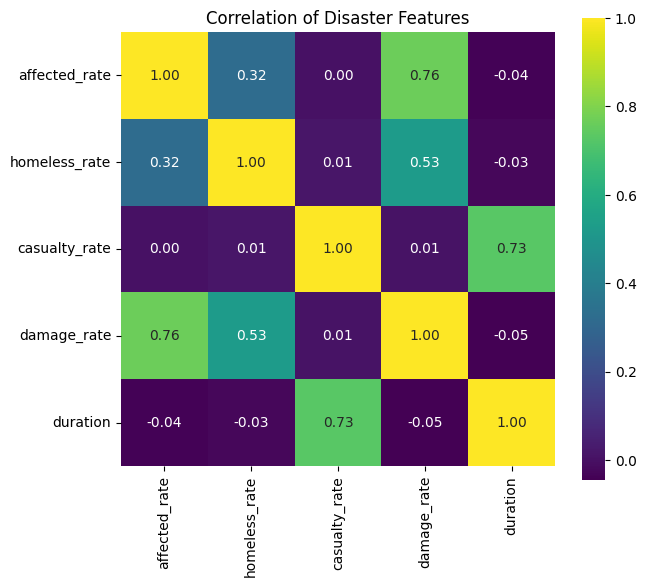

In [78]:

numeric_features = PH_disaster_df[
    [
        "affected_rate",
        "homeless_rate",
        "casualty_rate",
        "damage_rate",
        "duration"
    ]
]

corr=numeric_features.corr()

plt.figure(figsize=(7,6))
plt.imshow

plt.title("Correlation of Disaster Features")
sns.heatmap(corr,
            annot=True,
            cmap="viridis",
            fmt=".2f",
            square=True)

plt.show()

## 1.8 Getting top 10 cities
Getting top 10 cities prone to disasters based on the number of disaster events recorded in the dataset


In [79]:
# the top 10 cities prone to disasters based on the number of disaster events recorded in the dataset
disaster_vulnerability_place=PH_disaster_df.groupby("nearest_city")["disaster_type"].count().sort_values(ascending=False)[:10]
disaster_vulnerability_place

nearest_city
Tuguegarao          49
Santiago            43
Mandaluyong City    38
Lubao               37
Canagatan           36
Guinobatan          34
Laoag               33
Bayombong           33
Virac               31
Naguilian           30
Name: disaster_type, dtype: int64

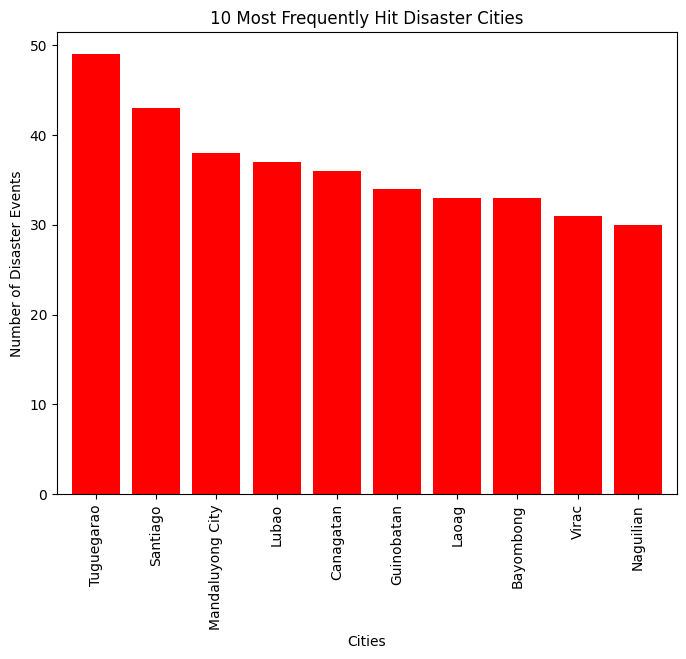

In [80]:
plt.figure(figsize=(8,6))
plt.title("10 Most Frequently Hit Disaster Cities")
disaster_vulnerability_place.plot(kind="bar", width=0.8, color="red")
plt.xlabel("Cities")
plt.ylabel("Number of Disaster Events")
plt.show()

## 1.9  Getting the Frequency Distribution of Disaster that appearred since 1980

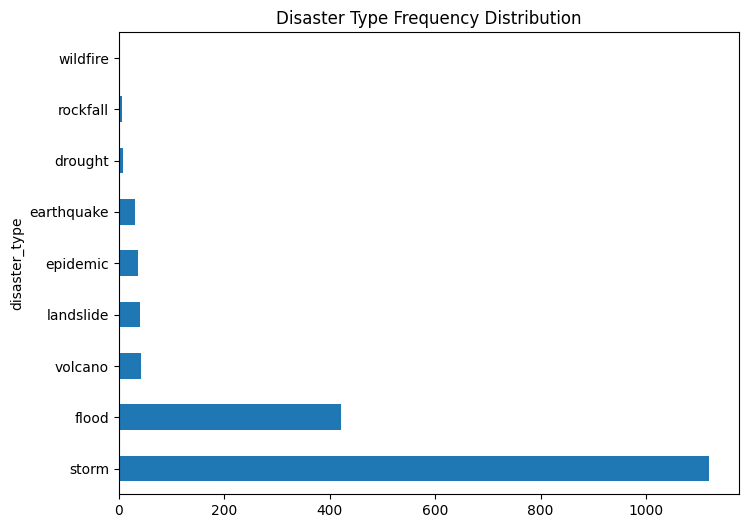

In [81]:
disaster=PH_disaster_df.groupby("disaster_type")["nearest_city"].count().sort_values(ascending=False)
plt.figure(figsize=(8,6))
plt.title("Disaster Type Frequency Distribution")
plt.xlabel("counts")
plt.ylabel("disaster type")
disaster.plot(kind="barh")
plt.show()

## 1.10 Relief Priority (Target Variable)

The original datasets did not contain a predefined **Relief Priority** label. Therefore, the target variable was generated from the engineered **Priority Score** using **quantile-based discretization** (`pd.qcut`).

Unlike fixed interval binning, **quantile binning** divides the Priority Score into three groups containing approximately equal numbers of disaster events. This approach produces a balanced target distribution, which is beneficial for training a multi-class classification model.

The Relief Priority categories were defined as follows:

| Quantile | Relief Priority |
|----------|-----------------|
| Lowest 33.3% | Low |
| Middle 33.3% | Medium |
| Highest 33.3% | High |




Using quantile-based categorization ensures that each priority class contains approximately one-third of the observations. This balanced class distribution minimizes class imbalance, reduces prediction bias toward a single class, and enables the XGBoost classifier to learn representative patterns for all three priority levels.

In [82]:
PH_disaster_df["priority_score"]=(0.35*PH_disaster_df["affected_rate"])+(0.25*PH_disaster_df["homeless_rate"])+(0.20*PH_disaster_df["casualty_rate"])+(0.10*PH_disaster_df["damage_rate"])+(0.1*PH_disaster_df["duration"])
# divide the number of rows in the PH_disaster_df by 3 to have an even distribution of the priority score:
number_in_each_class=int(PH_disaster_df["priority_score"].shape[0]/3)
number_in_each_class


568

In [83]:
PH_disaster_df["relief_priority"]=pd.qcut(PH_disaster_df["priority_score"],q=3 ,labels=["Low","Medium","High"])
PH_disaster_df["relief_priority"].value_counts()

relief_priority
Low       568
Medium    568
High      568
Name: count, dtype: int64

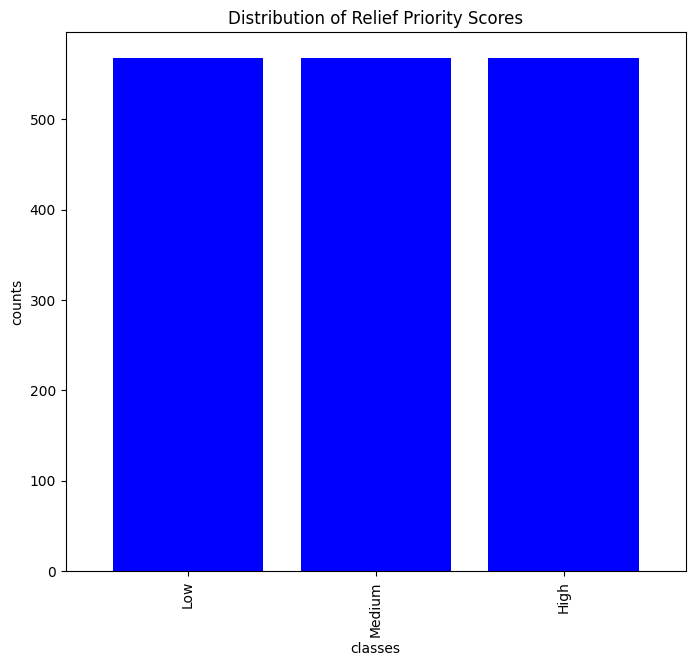

In [84]:
priority_relief_dist=PH_disaster_df["relief_priority"].value_counts()

plt.figure(figsize=(8,7))
plt.title("Distribution of Relief Priority Scores")
priority_relief_dist.plot(kind="bar", width=0.8, color="blue")
plt.xlabel("classes")
plt.ylabel("counts")
plt.show()

## 1.10 Outlier Analysis

Outlier analysis was conducted to identify unusually large or small observations within the engineered numerical features. Outliers may represent data entry errors, measurement inconsistencies, or genuine extreme disaster events. Detecting these values helps assess data quality and determine whether preprocessing techniques are necessary before model training.

Boxplots were used to visualize the distribution of each engineered feature and identify potential outliers based on the Interquartile Range (IQR) method. Observations falling outside the lower and upper whiskers were considered potential outliers.

The following engineered features were analyzed:

- Affected Rate
- Homeless Rate
- Casualty Rate
- Damage Rate
- Duration Score

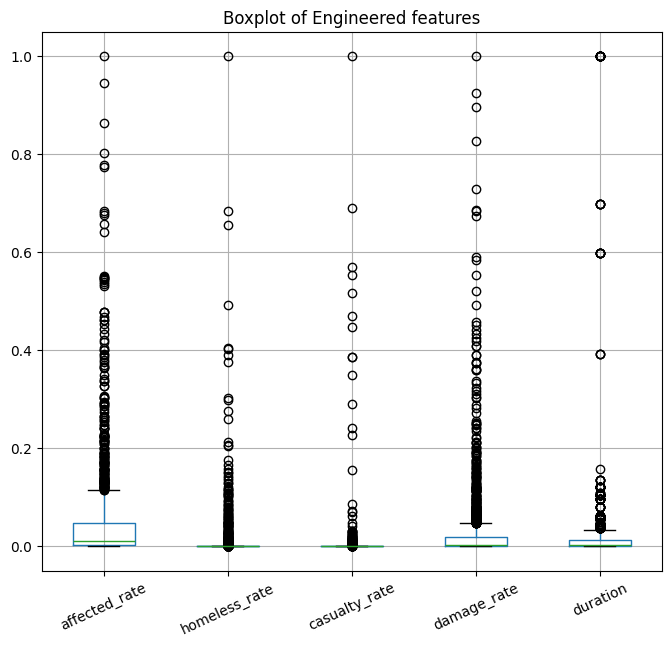

In [85]:
plt.figure(figsize=(8,7))
PH_disaster_df.boxplot(column=cols)
plt.title("Boxplot of Engineered features")
plt.xticks(rotation=25)
plt.show()

### Number of Detected Outliers

| Feature | Number of Outliers |
|---------|-------------------:|
| Affected Rate | 184 |
| Homeless Rate | 271 |
| Casualty Rate | 222 |
| Damage Rate | 243 |
| Duration Score | 209 |

### Findings

The analysis revealed that all engineered features contain a number of extreme observations. These outliers correspond to disaster events with exceptionally high population impact, economic losses, casualty rates, or prolonged durations.

Such observations are expected in historical disaster datasets because natural disasters vary significantly in severity. While many disaster events produce relatively minor impacts, others result in catastrophic consequences affecting large populations and causing substantial economic damage.

Rather than removing these observations, the identified outliers were retained because they represent **real historical disaster events** rather than data entry or measurement errors. Preserving these extreme cases is essential for the disaster relief prioritization system, as the objective is to accurately identify and prioritize high-impact disasters requiring immediate humanitarian response.

Furthermore, the selected machine learning algorithm, **XGBoost**, is a tree-based ensemble model that is inherently robust to outliers. Consequently, no additional outlier removal or transformation was applied before model training.

In [86]:
# Detecting outliers using the IQR method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return len(outliers)

In [87]:
for col in cols:
    print(detect_outliers(PH_disaster_df,col))

184
271
222
243
209


## 1.12 Saving Proceesed("the cleaned one") Data
Saving cleaned data in a proccessed folder 

In [88]:
import os

# Save the processed dataset
PH_disaster_df.to_csv(
    "../data/preprocessed/preprocessed_dataset.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
